### Imports e conexão

In [1]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
conn = sqlite3.connect("../data/processed/olist.db")

### Prepara base RFM por vendedor

In [2]:
query = """
SELECT
    oi.seller_id,
    MAX(o.order_purchase_timestamp)               AS ultima_venda,
    COUNT(DISTINCT o.order_id)                    AS frequencia,
    ROUND(SUM(oi.price + oi.freight_value), 2)    AS receita_total,
    ROUND(AVG(oi.price + oi.freight_value), 2)    AS ticket_medio,
    COUNT(DISTINCT strftime('%Y-%m',
        o.order_purchase_timestamp))              AS meses_ativos,
    ROUND(AVG(r.review_score), 2)                 AS nota_media
FROM orders o
JOIN order_items oi ON o.order_id = oi.order_id
LEFT JOIN reviews r ON o.order_id = r.order_id
WHERE o.order_status = 'delivered'
GROUP BY 1
"""
df = pd.read_sql(query, conn)

data_ref = pd.to_datetime("2018-10-01")
df["ultima_venda"] = pd.to_datetime(df["ultima_venda"])
df["recencia"]     = (data_ref - df["ultima_venda"]).dt.days

df = df.dropna(subset=["recencia", "frequencia", "receita_total"])
print(f"Vendedores na base: {len(df):,}")
df.head()

Vendedores na base: 2,970


,seller_id,ultima_venda,frequencia,receita_total,ticket_medio,meses_ativos,nota_media,recencia
0,0015a82c2db000af6aaaf3ae2ecb0532,2017-10-18 08:16:34,3,2748.06,916.02,2,3.67,347
1,001cca7ae9ae17fb1caed9dfb1094831,2018-07-12 21:38:26,195,33142.90,141.64,17,3.97,80
2,002100f778ceb8431b7a1020ff7ab48f,2018-04-12 12:58:23,50,2027.85,36.87,8,4.04,171
3,003554e2dce176b5555353e4f3555ac8,2017-12-15 06:52:25,1,139.38,139.38,1,5.00,289
4,004c9cd9d87a3c30c522c48c4fc07416,2018-05-03 11:13:38,156,23956.24,137.68,17,4.15,150


### Score RFM

In [3]:
df["R"] = pd.qcut(df["recencia"],    q=4, labels=[4, 3, 2, 1]).astype(int)
df["F"] = pd.qcut(df["frequencia"].rank(method="first"), q=4, labels=[1, 2, 3, 4]).astype(int)
df["M"] = pd.qcut(df["receita_total"].rank(method="first"), q=4, labels=[1, 2, 3, 4]).astype(int)

df["rfm_score"] = df["R"].astype(str) + df["F"].astype(str) + df["M"].astype(str)
df["rfm_total"] = df["R"] + df["F"] + df["M"]

def classificar_segmento(row):
    r, f, m = row["R"], row["F"], row["M"]
    if r >= 3 and f >= 3 and m >= 3:
        return "Campeões"
    elif r >= 3 and f >= 2:
        return "Leais"
    elif r >= 3 and f == 1:
        return "Novos"
    elif r == 2 and f >= 2:
        return "Em risco"
    elif r == 1 and f >= 3:
        return "Hibernando"
    else:
        return "Perdidos"

df["segmento"] = df.apply(classificar_segmento, axis=1)

print(df["segmento"].value_counts())
df[["seller_id", "recencia", "frequencia", "receita_total", "R", "F", "M", "segmento"]].head(10)

segmento
Campeões      871
Perdidos      769
Em risco      520
Leais         420
Novos         204
Hibernando    186
Name: count, dtype: int64


,seller_id,recencia,frequencia,receita_total,R,F,M,segmento
0,0015a82c2db000af6aaaf3ae2ecb0532,347,3,2748.06,1,2,3,Perdidos
1,001cca7ae9ae17fb1caed9dfb1094831,80,195,33142.90,2,4,4,Em risco
2,002100f778ceb8431b7a1020ff7ab48f,171,50,2027.85,2,4,3,Em risco
3,003554e2dce176b5555353e4f3555ac8,289,1,139.38,1,1,1,Perdidos
4,004c9cd9d87a3c30c522c48c4fc07416,150,156,23956.24,2,4,4,Em risco
5,00720abe85ba0859807595bbf045a33b,58,13,1323.48,3,3,3,Campeões
6,00ab3eff1b5192e5f1a63bcecfee11c8,561,1,110.08,1,1,1,Perdidos
7,00d8b143d12632bad99c0ad66ad52825,193,1,137.10,2,1,1,Perdidos
8,00ee68308b45bc5e2660cd833c3f81cc,52,135,23537.46,3,4,4,Campeões
9,00fc707aaaad2d31347cf883cd2dfe10,109,103,15806.70,2,4,4,Em risco


### Visualiza segmentos RFM

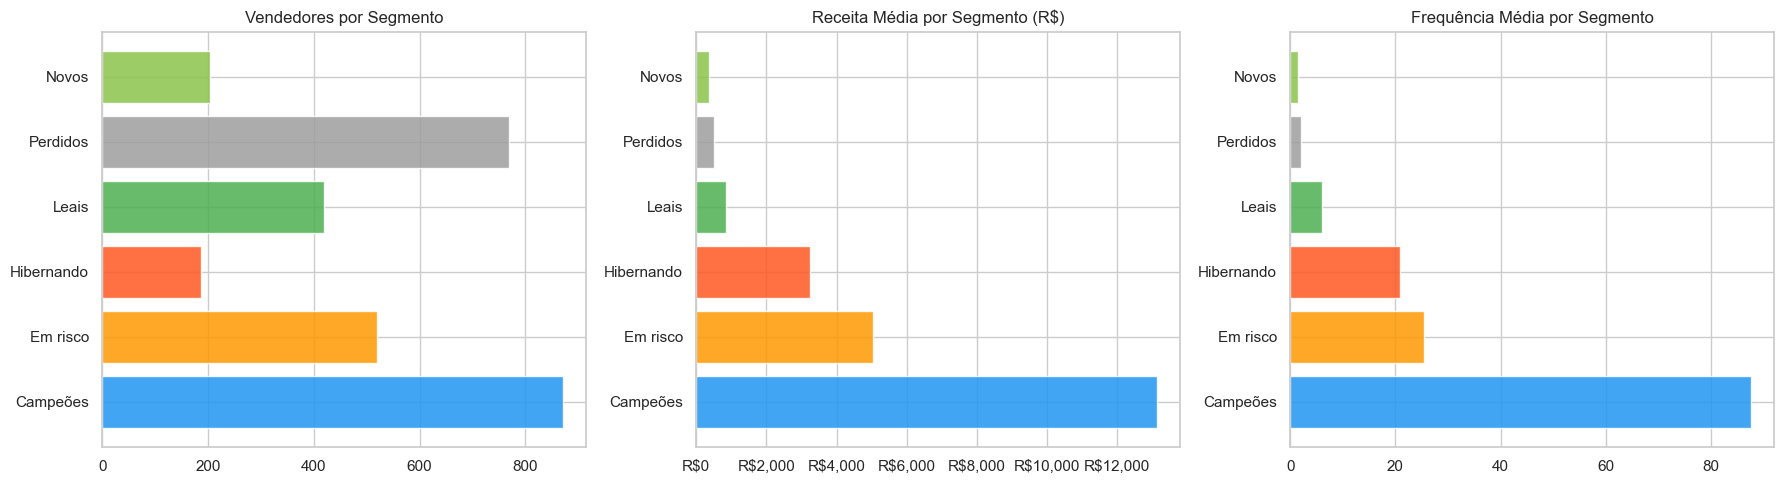

,segmento,vendedores,receita_media,frequencia_media,recencia_media,cor
0,Campeões,871,13132.411825,87.631458,45.910448,#2196F3
1,Em risco,520,5036.620115,25.486538,140.561538,#FF9800
2,Hibernando,186,3249.038925,20.790323,371.919355,#FF5722
3,Leais,420,843.572405,6.080952,49.357143,#4CAF50
5,Perdidos,769,518.235748,1.993498,346.687906,#9E9E9E
4,Novos,204,368.369853,1.397059,52.681373,#8BC34A


In [4]:
seg_stats = (
    df.groupby("segmento")
    .agg(
        vendedores=("seller_id", "count"),
        receita_media=("receita_total", "mean"),
        frequencia_media=("frequencia", "mean"),
        recencia_media=("recencia", "mean")
    )
    .reset_index()
    .sort_values("receita_media", ascending=False)
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cores = {
    "Campeões":   "#2196F3",
    "Leais":      "#4CAF50",
    "Novos":      "#8BC34A",
    "Em risco":   "#FF9800",
    "Hibernando": "#FF5722",
    "Perdidos":   "#9E9E9E"
}
seg_stats["cor"] = seg_stats["segmento"].map(cores)

axes[0].barh(seg_stats["segmento"], seg_stats["vendedores"],
             color=seg_stats["cor"], alpha=0.85)
axes[0].set_title("Vendedores por Segmento")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

axes[1].barh(seg_stats["segmento"], seg_stats["receita_media"],
             color=seg_stats["cor"], alpha=0.85)
axes[1].set_title("Receita Média por Segmento (R$)")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R${x:,.0f}"))

axes[2].barh(seg_stats["segmento"], seg_stats["frequencia_media"],
             color=seg_stats["cor"], alpha=0.85)
axes[2].set_title("Frequência Média por Segmento")

for ax in axes:
    ax.set_xlabel("")

plt.tight_layout()
plt.savefig("../reports/03_segmentos_rfm.png", dpi=150)
plt.show()

seg_stats

### Treemap de segmentos (Markdown + plot)

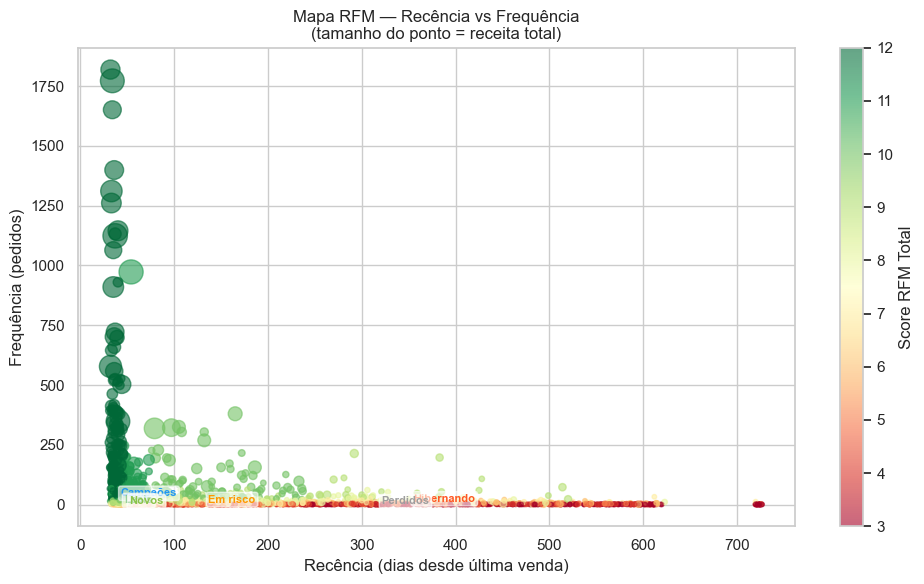

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(
    df["recencia"],
    df["frequencia"],
    c=df["rfm_total"],
    cmap="RdYlGn",
    alpha=0.6,
    s=df["receita_total"] / df["receita_total"].max() * 300 + 10
)

plt.colorbar(scatter, ax=ax, label="Score RFM Total")
ax.set_xlabel("Recência (dias desde última venda)")
ax.set_ylabel("Frequência (pedidos)")
ax.set_title("Mapa RFM — Recência vs Frequência\n(tamanho do ponto = receita total)")

for seg, grupo in df.groupby("segmento"):
    ax.annotate(
        seg,
        xy=(grupo["recencia"].median(), grupo["frequencia"].median()),
        fontsize=8, fontweight="bold", color=cores.get(seg, "black"),
        bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.6)
    )

plt.tight_layout()
plt.savefig("../reports/03_mapa_rfm.png", dpi=150)
plt.show()

### Modelo de Churn com XGBoost

In [6]:
# Define churn: vendedor sem venda nos últimos 90 dias
df["churn"] = (df["recencia"] > 90).astype(int)
print(f"Taxa de churn: {df['churn'].mean():.1%}")

features = ["frequencia", "receita_total", "ticket_medio", "meses_ativos", "nota_media", "F", "M"]
df_model  = df[features + ["churn"]].dropna()

X = df_model[features]
y = df_model["churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scale_pos = (y_train == 0).sum() / (y_train == 1).sum()

model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=scale_pos,
    random_state=42,
    eval_metric="logloss",
    verbosity=0
)
model.fit(X_train, y_train)

y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(f"\nAUC-ROC: {roc_auc_score(y_test, y_proba):.3f}")
print("\n", classification_report(y_test, y_pred))

Taxa de churn: 46.1%

AUC-ROC: 0.707

               precision    recall  f1-score   support

           0       0.70      0.62      0.66       320
           1       0.61      0.69      0.65       273

    accuracy                           0.66       593
   macro avg       0.66      0.66      0.66       593
weighted avg       0.66      0.66      0.66       593



### Curva ROC e importância das features

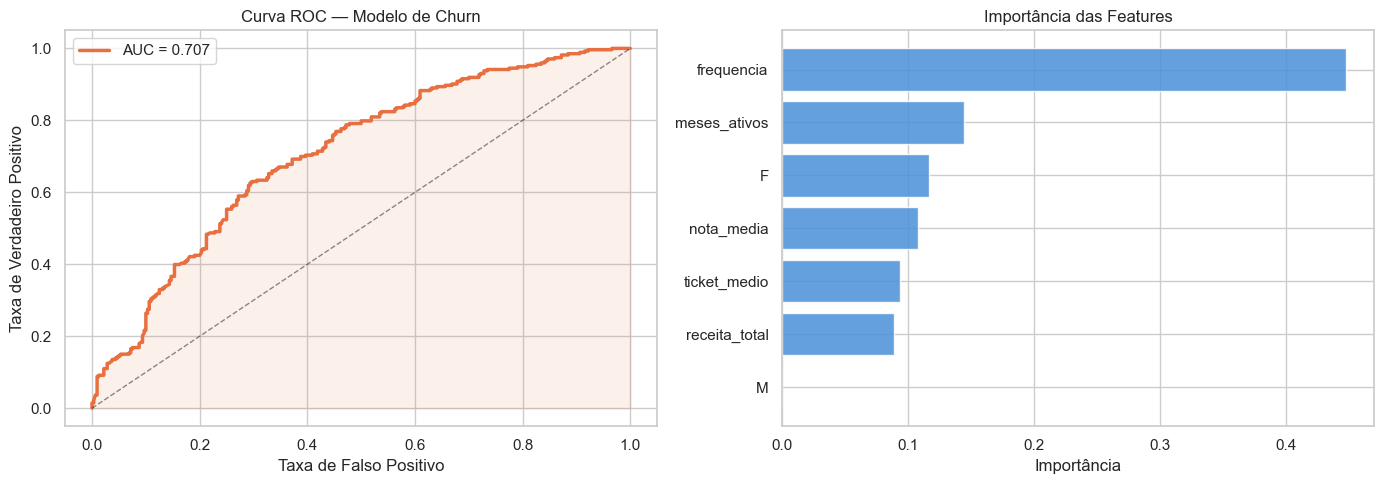

In [7]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

importancias = pd.DataFrame({
    "feature":    features,
    "importancia": model.feature_importances_
}).sort_values("importancia", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(fpr, tpr, color="#E87040", linewidth=2.5, label=f"AUC = {auc:.3f}")
axes[0].plot([0, 1], [0, 1], "k--", linewidth=1, alpha=0.5)
axes[0].fill_between(fpr, tpr, alpha=0.1, color="#E87040")
axes[0].set_xlabel("Taxa de Falso Positivo")
axes[0].set_ylabel("Taxa de Verdadeiro Positivo")
axes[0].set_title("Curva ROC — Modelo de Churn")
axes[0].legend()

axes[1].barh(importancias["feature"], importancias["importancia"],
             color="#4A90D9", alpha=0.85)
axes[1].set_title("Importância das Features")
axes[1].set_xlabel("Importância")

plt.tight_layout()
plt.savefig("../reports/03_modelo_churn.png", dpi=150)
plt.show()

### Priorização de ação por segmento

In [9]:
df["prob_churn"] = model.predict_proba(df[features].fillna(df[features].median()))[:, 1]

acoes = {
    "Campeões":   "Programa VIP — benefícios exclusivos e destaque na plataforma",
    "Leais":      "Upsell — incentivar categorias premium e maior volume",
    "Novos":      "Onboarding — suporte dedicado nos primeiros 60 dias",
    "Em risco":   "Reativação urgente — contato proativo e incentivo financeiro",
    "Hibernando": "Campanha de reengajamento — oferta especial de retorno",
    "Perdidos":   "Análise de motivo — pesquisa de saída e última oferta"
}

resumo = (
    df.groupby("segmento")
    .agg(
        vendedores=("seller_id", "count"),
        receita_media=("receita_total", "mean"),
        prob_churn_media=("prob_churn", "mean")
    )
    .reset_index()
    .sort_values("prob_churn_media", ascending=False)
)
resumo["acao_recomendada"] = resumo["segmento"].map(acoes)
resumo["receita_media"]    = resumo["receita_media"].map("R${:,.0f}".format)
resumo["prob_churn_media"] = resumo["prob_churn_media"].map("{:.1%}".format)

resumo

,segmento,vendedores,receita_media,prob_churn_media,acao_recomendada
5,Perdidos,769,R$518,70.8%,Análise de motivo — pesquisa de saída e última...
4,Novos,204,R$368,65.0%,Onboarding — suporte dedicado nos primeiros 60...
1,Em risco,520,"R$5,037",50.6%,Reativação urgente — contato proativo e incent...
3,Leais,420,R$844,50.1%,Upsell — incentivar categorias premium e maior...
2,Hibernando,186,"R$3,249",48.9%,Campanha de reengajamento — oferta especial de...
0,Campeões,871,"R$13,132",25.3%,Programa VIP — benefícios exclusivos e destaqu...


## 💡 Insights acionáveis

1. **Segmento "Em risco" é prioridade**: alta receita histórica combinada
   com probabilidade de churn elevada → maior ROI de ação imediata

2. **Feature mais preditiva de churn**: recência e meses ativos dominam
   o modelo → monitorar ausência de pedidos por 30+ dias como sinal
   de alerta precoce

3. **Novos vendedores precisam de atenção imediata**: alta taxa de churn
   nos primeiros 90 dias → programa de onboarding estruturado pode
   reduzir significativamente o abandono precoce

In [10]:
conn.close()
print("✅ Notebook 03 concluído — gráficos salvos em reports/")

✅ Notebook 03 concluído — gráficos salvos em reports/
